# Recitation 2
## Eigenvalue Decomposition, Multivariate Gaussians, and Hyperplanes / Halfspaces

This recitation covers three connected topics:

1. **Eigenvalue decomposition**
2. **Multivariate Gaussian distributions**
3. **Hyperplanes and halfspaces**

Throughout, we use the following Gaussian example:

$$
\mu =
\begin{bmatrix}
1\\
3
\end{bmatrix},
\qquad
\Sigma =
\begin{bmatrix}
1 & 0.8\\
0.8 & 1
\end{bmatrix}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set random seed for reproducibility
np.random.seed(42)

# 1. Eigenvalue decomposition

Start with a simple symmetric matrix

$$
A =
\begin{bmatrix}
3 & 1\\
1 & 3
\end{bmatrix}.
$$

An eigenvector $\mathbf v$ and its eigenvalue $\lambda$ satisfy

$$
A\mathbf v = \lambda \mathbf v.
$$

This means that when $A$ acts on an eigenvector, the direction is preserved and only its scale changes.

Because $A$ is symmetric, it has real eigenvalues and orthogonal eigenvectors.

In [2]:
# Construct a symmetric 2 x 2 matrix
A = np.array([
    [3.0, 1.0],
    [1.0, 3.0]
])

# eigh() is designed for real symmetric / Hermitian matrices.
# Eigenvectors are stored as the columns of eigenvectors_A.
eigenvalues_A, eigenvectors_A = np.linalg.eigh(A)

print("A:")
print(A)

print("\nEigenvalues:")
print(eigenvalues_A)

print("\nEigenvectors (stored as columns):")
print(eigenvectors_A)

A:
[[3. 1.]
 [1. 3.]]

Eigenvalues:
[2. 4.]

Eigenvectors (stored as columns):
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


## 1.1 Visualize the eigenvectors

The eigenvectors define special directions in the plane.

We draw them from the origin.

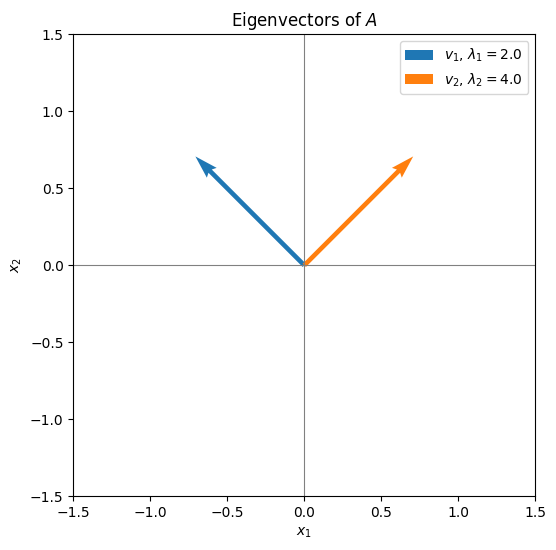

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

for i in range(2):
    v = eigenvectors_A[:, i]

    ax.quiver(
        0, 0,                 # starting point
        v[0], v[1],           # x- and y-components
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.010,
        color=["tab:blue", "tab:orange"][i],
        label=fr"$v_{i+1}$, $\lambda_{i+1}={eigenvalues_A[i]:.1f}$"
    )

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# aspect="equal"
# -> one unit on the x-axis has the same visual length as one unit on the y-axis
#
# adjustable="box"
# -> resize the plotting rectangle if needed to preserve that equal scale
ax.set_aspect("equal", adjustable="box")

ax.set_title("Eigenvectors of $A$")
ax.legend()
plt.show()

## 1.2 How does a general vector change through $A$?

Take

$$
\mathbf x =
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

Let

$$
V =
\begin{bmatrix}
| & |\\
\mathbf v_1 & \mathbf v_2\\
| & |
\end{bmatrix},
\qquad
\Lambda =
\begin{bmatrix}
\lambda_1 & 0\\
0 & \lambda_2
\end{bmatrix}.
$$

Because the eigenvectors form an orthonormal basis,

$$
A = V\Lambda V^T.
$$

We can understand $A\mathbf x$ in three steps:

### Step 1: project $x$ onto the eigenvector coordinates

$$
\mathbf c = V^T\mathbf x.
$$

### Step 2: rescale each coordinate by its eigenvalue

$$
\mathbf c' = \Lambda \mathbf c.
$$

### Step 3: transform back to the original coordinates

$$
A\mathbf x = V\mathbf c'.
$$

So $A$ acts by **projecting onto the eigenvectors, scaling each component, and recombining them**.

In [4]:
x = np.array([2.0, 1.0])

V_A = eigenvectors_A
Lambda_A = np.diag(eigenvalues_A)

# Step 1: coordinates of x in the eigenvector basis
c = V_A.T @ x

# Step 2: rescale each coordinate by the corresponding eigenvalue
scaled_c = Lambda_A @ c

# Step 3: return to the original coordinates
Ax_from_eigendecomp = V_A @ scaled_c

# Direct multiplication for comparison
Ax_direct = A @ x

print("x =", x)
print("\nCoordinates in the eigenvector basis V^T x:")
print(c)

print("\nAfter multiplying each coordinate by its eigenvalue:")
print(scaled_c)

print("\nAx from eigendecomposition:")
print(Ax_from_eigendecomp)

print("\nAx from direct matrix multiplication:")
print(Ax_direct)

print("\nDo they match?")
print(np.allclose(Ax_from_eigendecomp, Ax_direct))

x = [2. 1.]

Coordinates in the eigenvector basis V^T x:
[-0.70710678  2.12132034]

After multiplying each coordinate by its eigenvalue:
[-1.41421356  8.48528137]

Ax from eigendecomposition:
[7. 5.]

Ax from direct matrix multiplication:
[7. 5.]

Do they match?
True


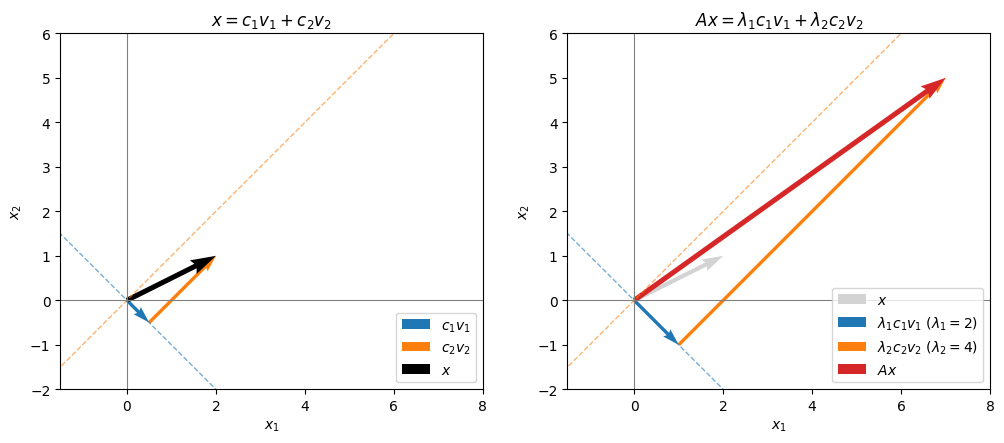

In [5]:
# x  = c1 v1 + c2 v2
# Ax = (λ1 c1) v1 + (λ2 c2) v2   -> each eigen-coordinate is multiplied by its eigenvalue
comp1, comp2 = c[0] * V_A[:, 0], c[1] * V_A[:, 1]
scaled1, scaled2 = eigenvalues_A[0] * comp1, eigenvalues_A[1] * comp2

def draw(ax, start, vec, color, label, width=0.008):
    ax.quiver(start[0], start[1], vec[0], vec[1], angles="xy", scale_units="xy",
              scale=1, color=color, width=width, label=label)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax in axes:
    for i, col in enumerate(["tab:blue", "tab:orange"]):
        v = V_A[:, i]
        ax.plot([-10 * v[0], 10 * v[0]], [-10 * v[1], 10 * v[1]], "--", lw=1, color=col, alpha=0.6)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)

# Left: x decomposed along the eigenvectors
draw(axes[0], [0, 0], comp1, "tab:blue", r"$c_1 v_1$")
draw(axes[0], comp1, comp2, "tab:orange", r"$c_2 v_2$")
draw(axes[0], [0, 0], x, "black", r"$x$", width=0.012)
axes[0].set_title(r"$x = c_1 v_1 + c_2 v_2$")

# Right: same components, each multiplied by its eigenvalue
draw(axes[1], [0, 0], x, "lightgray", r"$x$", width=0.010)
draw(axes[1], [0, 0], scaled1, "tab:blue", fr"$\lambda_1 c_1 v_1$ ($\lambda_1={eigenvalues_A[0]:.0f}$)")
draw(axes[1], scaled1, scaled2, "tab:orange", fr"$\lambda_2 c_2 v_2$ ($\lambda_2={eigenvalues_A[1]:.0f}$)")
draw(axes[1], [0, 0], Ax_direct, "tab:red", r"$Ax$", width=0.012)
axes[1].set_title(r"$Ax = \lambda_1 c_1 v_1 + \lambda_2 c_2 v_2$")

for ax in axes:
    ax.set_xlim(-1.5, 8)
    ax.set_ylim(-2, 6)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(loc="lower right")

plt.show()


## 1.3 Why this connects naturally to Gaussians

A covariance matrix is also symmetric.

Therefore, the same eigendecomposition idea can be applied to a covariance matrix:

$$
\Sigma = V\Lambda V^T.
$$

For a Gaussian:

- the eigenvectors of $\Sigma$ give the principal directions of the distribution;
- the eigenvalues give the variances along those directions.

# 2. Multivariate Gaussian distributions

A $d$-dimensional Gaussian distribution is described by a mean vector $\mu$ and covariance matrix $\Sigma$:

$$
p(\mathbf x)
=
\frac{1}
{(2\pi)^{d/2}|\Sigma|^{1/2}}
\exp\left[
-\frac12
(\mathbf x-\mu)^T
\Sigma^{-1}
(\mathbf x-\mu)
\right].
$$

The mean determines the **center**.

The covariance determines the **spread, correlation, and orientation**.

## 2.1 Standard Gaussian: 3-D probability-density surface

First consider the standard 2-D Gaussian:

$$
\mu =
\begin{bmatrix}
0\\
0
\end{bmatrix},
\qquad
\Sigma =
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix}.
$$

In 3-D, the horizontal axes are $x_1$ and $x_2$, while the vertical axis is the probability density $p(x_1,x_2)$.

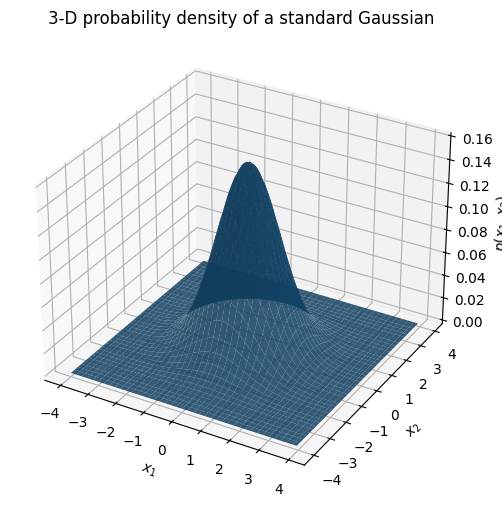

In [6]:
mean_std = np.array([0.0, 0.0])
cov_std = np.eye(2)

# Create a multivariate Gaussian distribution object.
rv_std = multivariate_normal(mean_std, cov_std)

# Create a 2-D coordinate grid.
sx1, sx2 = np.mgrid[-4:4:.05, -4:4:.05]

# Combine the coordinate grids so each location stores [x1, x2].
standard_positions = np.dstack((sx1, sx2))

# Evaluate the PDF at every grid location.
standard_pdf = rv_std.pdf(standard_positions)

# 3-D surface
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(sx1, sx2, standard_pdf, alpha=0.85)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$p(x_1,x_2)$")
ax.set_title("3-D probability density of a standard Gaussian")
plt.show()

## 2.2 Standard Gaussian: contours only

A contour plot converts the 3-D surface into a 2-D map.

For a surface

$$
z=f(x_1,x_2),
$$

a contour line connects locations with the **same value of $z$**.

Here,

$$
z=p(x_1,x_2),
$$

so each contour connects points with the **same Gaussian probability density**.

For the standard Gaussian, $\Sigma=I$, so $p(\mathbf x)\propto\exp\left(-\tfrac12\|\mathbf x\|^2\right)$ depends only on the distance from the mean. The contours are therefore **circles** centered at the mean.

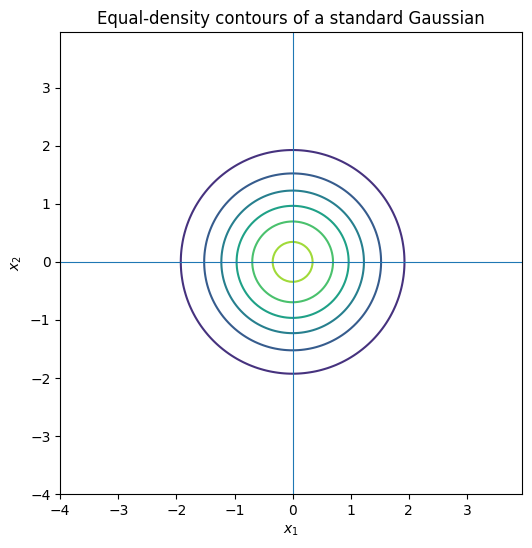

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

# contour(x, y, z)
# -> draws lines connecting points that have the same z value
#
# Here:
#   x = x1 coordinates
#   y = x2 coordinates
#   z = Gaussian probability density
#
# levels=6 means draw 6 density levels.
ax.contour(sx1, sx2, standard_pdf, levels=6)

# Draw coordinate-axis reference lines.
# axhline(y=...) draws a horizontal line.
# axvline(x=...) draws a vertical line.
ax.axhline(y=0, linewidth=0.8)
ax.axvline(x=0, linewidth=0.8)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Equal-density contours of a standard Gaussian")
plt.show()

## 2.3 Add samples

The contour lines show the **theoretical distribution**.

Now sample points from that distribution and superimpose them on the contours.

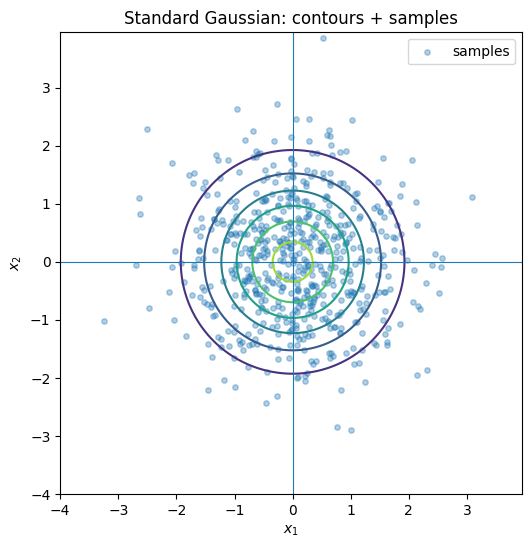

In [8]:
# rvs(size=n)
# -> draws n random samples from the distribution
# -> each sample has 2 values because this is a 2-D Gaussian
# -> the resulting array therefore has shape (n, 2)
X_std = rv_std.rvs(size=600)

fig, ax = plt.subplots(figsize=(6, 6))
ax.contour(sx1, sx2, standard_pdf, levels=6)
ax.scatter(
    X_std[:, 0],
    X_std[:, 1],
    alpha=0.35,
    s=15,
    label="samples"
)

ax.axhline(y=0, linewidth=0.8)
ax.axvline(x=0, linewidth=0.8)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Standard Gaussian: contours + samples")
ax.legend()
plt.show()

## 2.4 Return to the original correlated Gaussian

Now use the original example:

$$
\mu =
\begin{bmatrix}
1\\
3
\end{bmatrix},
\qquad
\Sigma =
\begin{bmatrix}
1 & 0.8\\
0.8 & 1
\end{bmatrix}.
$$

The positive off-diagonal terms make the variables positively correlated, so the distribution is elongated from lower-left to upper-right.

In [9]:
n = 1000

mean = np.array([1.0, 3.0])
cov = np.array([
    [1.0, 0.8],
    [0.8, 1.0]
])

# multivariate_normal(mean, cov)
# -> creates a multivariate Gaussian distribution
#    defined by the mean vector and covariance matrix
#
# We store the distribution in rv so that we can later:
#   rv.rvs(...) -> generate random samples
#   rv.pdf(...) -> calculate probability density values
rv = multivariate_normal(mean, cov)

# Generate samples.
# size=n controls how many samples are drawn.
# The dimensionality comes from mean/cov, so X has shape (n, 2).
X = rv.rvs(size=n)

# Build a grid for evaluating the density.
x1, x2 = np.mgrid[-2:5:.03, 0:6:.03]

# Combine x1 and x2 so that every grid location stores one point [x1, x2].
# positions has shape (rows, columns, 2).
positions = np.dstack((x1, x2))

pdf_values = rv.pdf(positions)

print("X shape:", X.shape)
print("Grid shape:", positions.shape)

X shape: (1000, 2)
Grid shape: (234, 200, 2)


### 2.4.1 3-D view of the correlated Gaussian

The same distribution can now be viewed as a 3-D probability-density surface.

Compared with the standard Gaussian, the base of the surface is elongated and rotated because of the covariance.

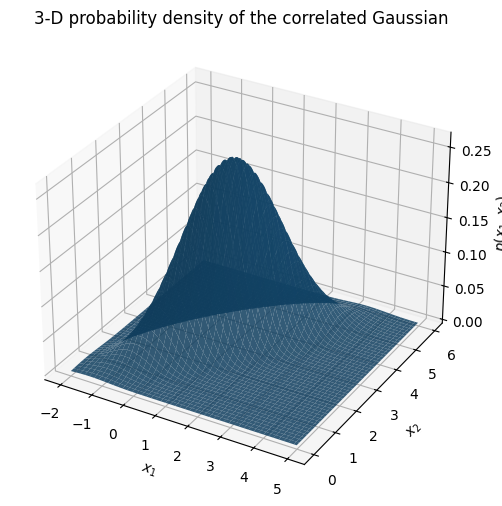

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(x1, x2, pdf_values, alpha=0.85)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$p(x_1,x_2)$")
ax.set_title("3-D probability density of the correlated Gaussian")
plt.show()

### 2.4.2 Contours only

Each contour connects points with the same value of

$$
p(x_1,x_2).
$$

Since $p(\mathbf x)$ depends on $\mathbf x$ only through the quadratic form $(\mathbf x-\mu)^T\Sigma^{-1}(\mathbf x-\mu)$, each contour is a set of the form

$$
\{\mathbf x : (\mathbf x-\mu)^T\Sigma^{-1}(\mathbf x-\mu)=k^2\}
$$

for some constant $k>0$. This is an **ellipse** centered at $\mu$: its axes point along the eigenvectors of $\Sigma$, and its semi-axis lengths are $k\sqrt{\lambda_i}$ (see Section 2.5).

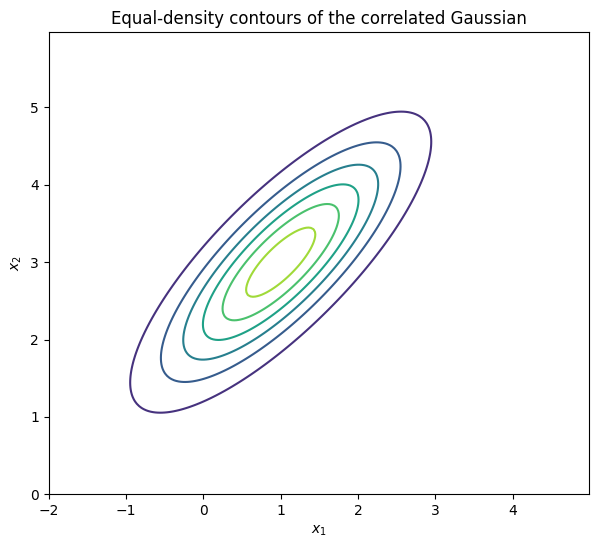

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.contour(x1, x2, pdf_values, levels=6)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Equal-density contours of the correlated Gaussian")
ax.set_aspect("equal", adjustable="box")
plt.show()

### 2.4.3 Add the samples

Now superimpose the random samples.

The scatter plot shows sampled observations, while the contours show the underlying theoretical probability density.

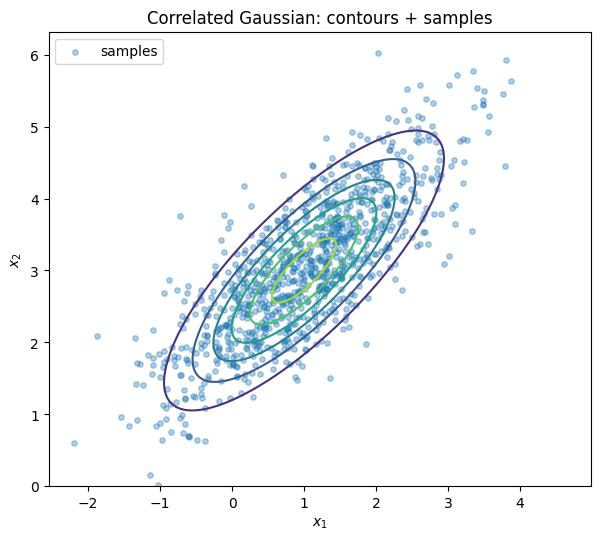

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.contour(x1, x2, pdf_values, levels=6)
ax.scatter(
    X[:, 0],
    X[:, 1],
    label="samples",
    alpha=0.35,
    s=15
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Correlated Gaussian: contours + samples")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

### 2.4.4 What does the covariance matrix tell us?

The covariance matrix is

$$
\Sigma =
\begin{bmatrix}
1 & 0.8 \\
0.8 & 1
\end{bmatrix}
$$

The diagonal entries describe the variation of each variable.

The off-diagonal entries describe how the two variables vary together.

The off-diagonal terms represent the covariance between $x_1$ and $x_2$.

- Positive covariance: the two variables tend to vary in the same direction, so the data cloud tilts from lower-left to upper-right.
- Negative covariance: the two variables tend to vary in opposite directions, so the data cloud tilts from upper-left to lower-right.

Here the covariance is $0.8 > 0$, so the Gaussian is tilted upward.

In [13]:
print("Covariance matrix:")
print(cov)

print("\nVariance of x1:", cov[0, 0])
print("Variance of x2:", cov[1, 1])
print("Covariance between x1 and x2:", cov[0, 1])

Covariance matrix:
[[1.  0.8]
 [0.8 1. ]]

Variance of x1: 1.0
Variance of x2: 1.0
Covariance between x1 and x2: 0.8


## Compare three covariance matrices

We now change only the correlation term.

The marginal variances stay the same, but the orientation of the Gaussian changes.

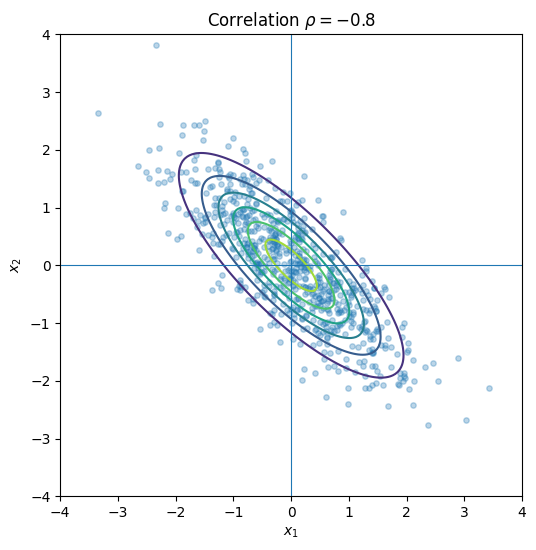

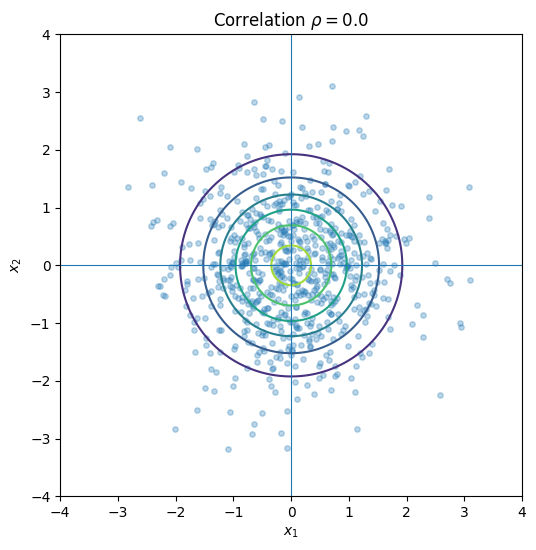

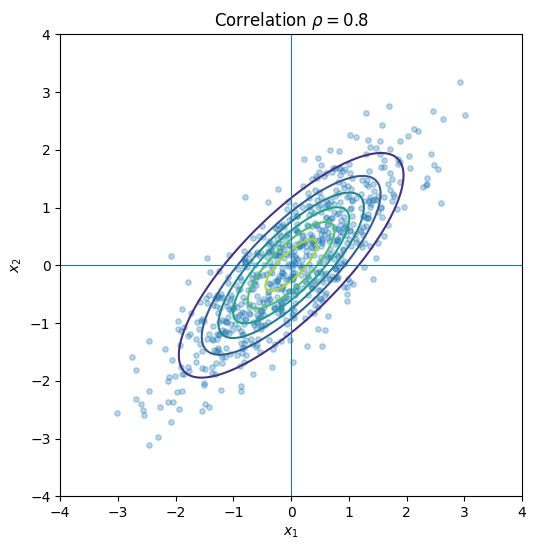

In [14]:
def plot_gaussian_with_rho(rho, n=700):
    local_mean = np.array([0.0, 0.0])
    local_cov = np.array([
        [1.0, rho],
        [rho, 1.0]
    ])

    local_rv = multivariate_normal(local_mean, local_cov)
    local_X = local_rv.rvs(size=n)

    g1, g2 = np.mgrid[-4:4:.04, -4:4:.04]
    grid_positions = np.dstack((g1, g2))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(local_X[:, 0], local_X[:, 1], alpha=0.30, s=15)
    ax.contour(g1, g2, local_rv.pdf(grid_positions), levels=6)

    ## ax.axhline(y, xmin=0, xmax=1, linewidth=...)
    ax.axhline(0, linewidth=0.8)
    # ax.axvline(x, ymin=0, ymax=1, linewidth=...)
    ax.axvline(0, linewidth=0.8)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(f"Correlation $\\rho={rho}$")

    plt.show()


plot_gaussian_with_rho(-0.8)
plot_gaussian_with_rho(0.0)
plot_gaussian_with_rho(0.8)

## 2.5 Eigendecomposition of the covariance matrix

For the covariance matrix,

$$
\Sigma \mathbf v = \lambda \mathbf v.
$$

For a covariance matrix:

- **eigenvectors** give the principal directions of the data;
- **eigenvalues** give the variance along those directions.

Because $\Sigma$ is symmetric, its eigenvectors can be chosen to be orthogonal.

In [15]:
# eigh() is preferred here because covariance matrices are symmetric.
eigenvalues, eigenvectors = np.linalg.eigh(cov)

print("Covariance matrix:")
print(cov, "\n")

for i in range(len(eigenvalues)):
    print(f"Eigenvalue {i+1}: {eigenvalues[i]:.3f}")
    print(f"Eigenvector {i+1}: {eigenvectors[:, i]}")
    print()

# Check with the samples: project the centered samples onto each eigenvector.
# The variance of each projection should be close to the corresponding eigenvalue.
projections = (X - mean) @ eigenvectors
for i in range(len(eigenvalues)):
    print(f"Sample variance along eigenvector {i+1}: {np.var(projections[:, i]):.3f}"
          f"  (eigenvalue {eigenvalues[i]:.3f})")


Covariance matrix:
[[1.  0.8]
 [0.8 1. ]] 

Eigenvalue 1: 0.200
Eigenvector 1: [-0.70710678  0.70710678]

Eigenvalue 2: 1.800
Eigenvector 2: [0.70710678 0.70710678]

Sample variance along eigenvector 1: 0.200  (eigenvalue 0.200)
Sample variance along eigenvector 2: 1.717  (eigenvalue 1.800)


### 2.5.1 Add the eigenvectors starting from the mean

The eigenvectors show the principal directions of the data distribution.

The eigenvalue associated with each eigenvector measures the variance along that direction.

In the visualization below, each eigenvector arrow is scaled by

$$
2\sqrt{\lambda},
$$

so each arrow spans two standard deviations along its direction.

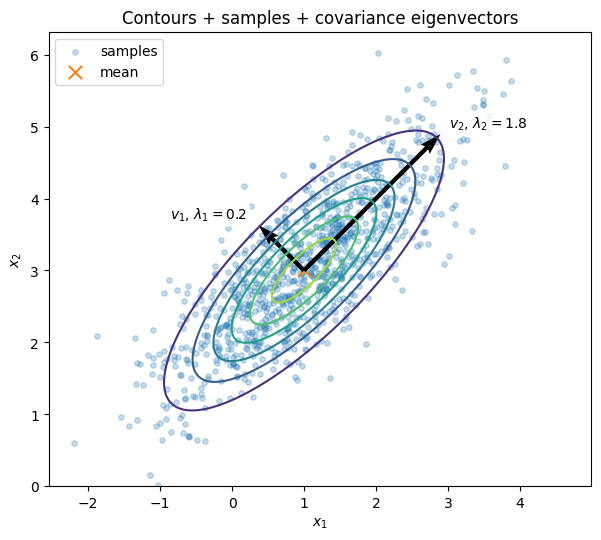

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.contour(x1, x2, pdf_values, levels=6)
ax.scatter(X[:, 0], X[:, 1], alpha=0.25, s=15, label="samples")
ax.scatter(mean[0], mean[1], marker="x", s=90, label="mean")

for i in range(2):
    direction = eigenvectors[:, i]

    # Eigenvalue = variance along this eigenvector.
    # sqrt(eigenvalue) = standard deviation along this direction.
    # The factor 2 makes each arrow span two standard deviations.
    length = 2 * np.sqrt(eigenvalues[i])

    dx = length * direction[0]
    dy = length * direction[1]

    # Draw the eigenvector as an arrow starting from the Gaussian mean.
    ax.quiver(
        mean[0], mean[1],   # starting point of the arrow
        dx, dy,             # x- and y-components of the arrow
        angles="xy",        # interpret direction in x-y coordinates
        scale_units="xy",   # use x-y data units for arrow length
        scale=1,            # do not automatically rescale the arrow
        width=0.008         # arrow thickness
    )

    # Label each arrow with its eigenvalue.
    ax.annotate(
        fr"$v_{i+1}$, $\lambda_{i+1}={eigenvalues[i]:.1f}$",
        xy=(mean[0] + dx, mean[1] + dy),
        xytext=(-8, 4) if i == 0 else (6, 4),
        textcoords="offset points",
        ha="right" if i == 0 else "left",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Contours + samples + covariance eigenvectors")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

## 2.6 Reconstruct the covariance matrix

Because a covariance matrix is symmetric,

$$
\Sigma = V\Lambda V^T,
$$

where

- $V$ contains the eigenvectors as columns;
- $\Lambda$ is a diagonal matrix containing the eigenvalues.

This is the same eigendecomposition idea used for the matrix $A$ in Topic 1.

In [17]:
V = eigenvectors
Lambda = np.diag(eigenvalues)

print("V:")
print(V)

print("\nLambda:")
print(Lambda)

cov_reconstructed = V @ Lambda @ V.T

print("\nOriginal covariance:")
print(cov)

print("\nReconstructed covariance V @ Lambda @ V.T:")
print(cov_reconstructed)

print("\nAre they approximately equal?")
print(np.allclose(cov, cov_reconstructed))

V:
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]

Lambda:
[[0.2 0. ]
 [0.  1.8]]

Original covariance:
[[1.  0.8]
 [0.8 1. ]]

Reconstructed covariance V @ Lambda @ V.T:
[[1.  0.8]
 [0.8 1. ]]

Are they approximately equal?
True


# 3. Hyperplanes and halfspaces

In two dimensions, a hyperplane is a **line**:

$$
\mathbf a^T\mathbf x-b=0.
$$

For

$$
\mathbf a =
\begin{bmatrix}
a_1\\
a_2
\end{bmatrix},
\qquad
\mathbf x =
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix},
$$

the equation becomes

$$
a_1x_1+a_2x_2=b.
$$

The two parameters have different geometric roles:

- **$\mathbf a$** determines the orientation of the line.  
  It is a normal vector, so it is perpendicular to the line.
- **$b$** determines the offset of the line from the origin.  
  Changing $b$ while keeping $\mathbf a$ fixed moves the line **parallel to itself**.

The signed distance from the origin to the line, measured along the normal direction, is

$$
\frac{b}{\|\mathbf a\|}.
$$

We will use

$$
\mathbf a=
\begin{bmatrix}
1\\
2
\end{bmatrix}.
$$

Then

$$
x_1+2x_2=b.
$$

We deliberately choose an $\mathbf a$ that is **not** parallel to an eigenvector of $\Sigma$, so the normal vector is not confused with the principal directions of the Gaussian.

In [18]:
a_hp = np.array([1.0, 2.0])

# We will compare two different offsets using the same normal vector a.
b0 = 0.0
b = 7.0

print("a =", a_hp)
print("b0 =", b0)
print("b  =", b)

print(f"\nDistance of the b={b:g} line from the origin:")
print(abs(b) / np.linalg.norm(a_hp))

a = [1. 2.]
b0 = 0.0
b  = 7.0

Distance of the b=7 line from the origin:
3.1304951684997055


## 3.1 What does $b$ do?

Keep the same normal vector

$$
\mathbf a=
\begin{bmatrix}
1\\
2
\end{bmatrix}.
$$

If $b=0$,

$$
x_1+2x_2=0,
$$

so the line passes through the origin.

If $b=7$,

$$
x_1+2x_2=7,
$$

the line has the **same orientation**, but it is shifted away from the origin.

Notice that the Gaussian mean is

$$
\mu=
\begin{bmatrix}
1\\
3
\end{bmatrix},
$$

and

$$
\mathbf a^T\mu=1+2\cdot 3=7.
$$

Therefore, choosing $b=7$ makes the hyperplane pass directly through the Gaussian mean.

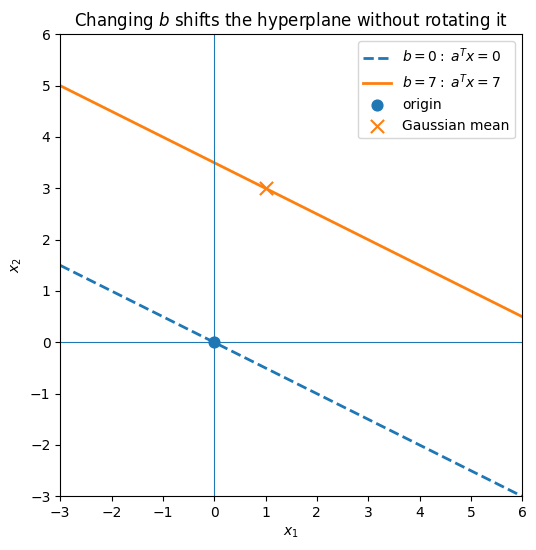

In [19]:
line_x1 = np.linspace(-3, 6, 400)

# a1*x1 + a2*x2 = b
# -> x2 = (b - a1*x1) / a2
line_b0_x2 = (b0 - a_hp[0] * line_x1) / a_hp[1]
line_b_x2 = (b - a_hp[0] * line_x1) / a_hp[1]

fig, ax = plt.subplots(figsize=(7, 6))

# b = 0: passes through the origin
ax.plot(
    line_x1, line_b0_x2,
    linestyle="--",
    linewidth=2,
    label=r"$b=0:\; a^T x=0$"
)

# b = 7: same orientation, shifted parallel to itself
ax.plot(
    line_x1, line_b_x2,
    linewidth=2,
    label=fr"$b={b:g}:\; a^T x={b:g}$"
)

ax.scatter(0, 0, marker="o", s=60, label="origin")
ax.scatter(mean[0], mean[1], marker="x", s=90, label="Gaussian mean")

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_xlim(-3, 6)
ax.set_ylim(-3, 6)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Changing $b$ shifts the hyperplane without rotating it")
ax.legend()
plt.show()

## 3.2 Why is $\mathbf a$ normal to the line?

For

$$
x_1+2x_2=7,
$$

a direction vector **along** the line is

$$
\mathbf d=
\begin{bmatrix}
2\\
-1
\end{bmatrix}.
$$

The normal vector is

$$
\mathbf a=
\begin{bmatrix}
1\\
2
\end{bmatrix}.
$$

Their dot product is

$$
\mathbf a^T\mathbf d
=
1(2)+2(-1)
=
0.
$$

A zero dot product means the two vectors are perpendicular.

So $\mathbf a$ is normal to the hyperplane.

a^T d = 0.0


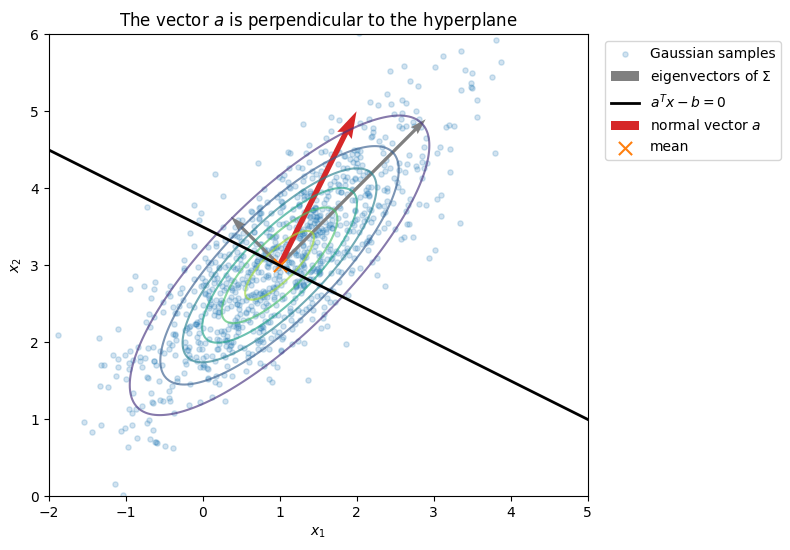

In [20]:
line_direction = np.array([2.0, -1.0])

print("a^T d =", a_hp @ line_direction)

fig, ax = plt.subplots(figsize=(7, 6))

# Keep the Gaussian context
ax.contour(x1, x2, pdf_values, levels=6, alpha=0.65)
ax.scatter(X[:, 0], X[:, 1], alpha=0.20, s=14, label="Gaussian samples")

# Covariance eigenvectors from Section 2.5.1 (column i = 2*sqrt(lambda_i) * v_i)
eig_arrows = eigenvectors * (2 * np.sqrt(eigenvalues))
ax.quiver(
    [mean[0], mean[0]], [mean[1], mean[1]],
    eig_arrows[0], eig_arrows[1],
    angles="xy", scale_units="xy", scale=1,
    width=0.006, color="gray",
    label=r"eigenvectors of $\Sigma$"
)

# Hyperplane with b = 7
ax.plot(
    line_x1, line_b_x2,
    color="k",
    linewidth=2,
    label=r"$a^T x-b=0$"
)

# Draw the normal vector a from the Gaussian mean.
# The mean lies on the line because a^T mean = b.
ax.quiver(
    mean[0], mean[1],
    a_hp[0], a_hp[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.010,
    color="tab:red",
    label=r"normal vector $a$"
)

ax.scatter(mean[0], mean[1], marker="x", s=90, label="mean")

ax.set_xlim(-2, 5)
ax.set_ylim(0, 6)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal", adjustable="box")
ax.set_title("The vector $a$ is perpendicular to the hyperplane")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

## 3.3 Halfspaces: the sign tells us which side a point lies on

The hyperplane

$$
\mathbf a^T\mathbf x-b=0
$$

divides the plane into two halfspaces:

$$
\mathbf a^T\mathbf x-b>0
$$

and

$$
\mathbf a^T\mathbf x-b<0.
$$

For each sampled point, calculate

$$
s=\mathbf a^T\mathbf x-b.
$$

- $s>0$: the point lies on the side pointed toward by the normal vector $\mathbf a$.
- $s<0$: the point lies on the opposite side.
- $s=0$: the point lies exactly on the hyperplane.

Because $b=7$ makes the boundary pass through the Gaussian mean, the split is easy to see on the same sample cloud.

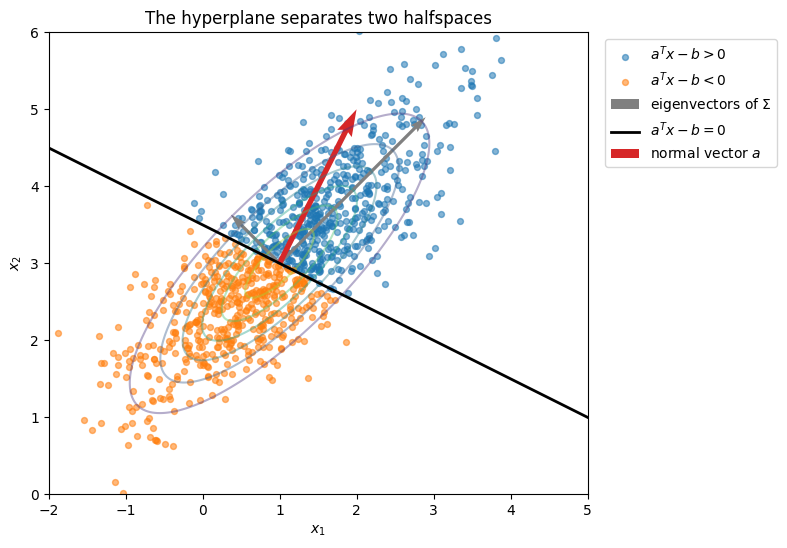

In [21]:
# X has shape (n, 2).
# X @ a_hp computes a^T x for every sample.
scores = X @ a_hp - b

positive = scores > 0
negative = scores < 0

fig, ax = plt.subplots(figsize=(7, 6))

ax.contour(x1, x2, pdf_values, levels=6, alpha=0.40)

ax.scatter(
    X[positive, 0],
    X[positive, 1],
    alpha=0.55,
    s=18,
    label=r"$a^T x-b>0$"
)

ax.scatter(
    X[negative, 0],
    X[negative, 1],
    alpha=0.55,
    s=18,
    label=r"$a^T x-b<0$"
)

# Covariance eigenvectors from Section 2.5.1 (column i = 2*sqrt(lambda_i) * v_i)
eig_arrows = eigenvectors * (2 * np.sqrt(eigenvalues))
ax.quiver(
    [mean[0], mean[0]], [mean[1], mean[1]],
    eig_arrows[0], eig_arrows[1],
    angles="xy", scale_units="xy", scale=1,
    width=0.006, color="gray",
    label=r"eigenvectors of $\Sigma$"
)

ax.plot(
    line_x1, line_b_x2,
    color="k",
    linewidth=2,
    label=r"$a^T x-b=0$"
)

ax.quiver(
    mean[0], mean[1],
    a_hp[0], a_hp[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.010,
    color="tab:red",
    label=r"normal vector $a$"
)

ax.set_xlim(-2, 5)
ax.set_ylim(0, 6)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal", adjustable="box")
ax.set_title("The hyperplane separates two halfspaces")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()